In [1]:
import sys
import os
import pandas as pd

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
%load_ext autoreload
%autoreload 2
pjoin = os.path.join

In [44]:
from src.plotting.visutil import CSVPlotter
from src.utils.mathutil import ABCDUtil
from src.utils.plotutil import PlotUtil
from scripts.PrepABCD import prep_sign_rwgt, read_two_channels_df, get_mbb_train_test, train_mlp_rwgt

## Pre-clean datasets

In [35]:
# Res1b_SS = pd.read_csv(f'{ABCD_dir}/Res1b_SS.csv', index_col=0)
# Res1b_OS = pd.read_csv(f'{ABCD_dir}/Res1b_OS.csv', index_col=0)
# Res2b_SS = pd.read_csv(f'{ABCD_dir}/Res2b_SS.csv', index_col=0)
# Res2b_OS = pd.read_csv(f'{ABCD_dir}/Res2b_OS.csv', index_col=0)
Res1b_SS, Res2b_SS, Res1b_OS, Res2b_OS = read_two_channels_df()

In [45]:
Res1b_SS = prep_sign_rwgt(Res1b_SS)
Res2b_SS = prep_sign_rwgt(Res2b_SS)
Res1b_OS = prep_sign_rwgt(Res1b_OS)
Res2b_OS = prep_sign_rwgt(Res2b_OS)

In [ ]:

print("1 b-tagged channel =====================================")
ABCDUtil.pearson_corr(df_1b, 'OS', 'DiJet_mass')
print("\n \n2 b-tagged channel =====================================")
ABCDUtil.pearson_corr(df_2b, 'OS', 'DiJet_mass')

1 b-tagged channel =====================================
Pearson Correlation Coefficient: -0.006784256350205142
P-value: 0.00017632639375193495

 
2 b-tagged channel =====================================
Pearson Correlation Coefficient: -0.001979010661664165
P-value: 0.18393738898948614


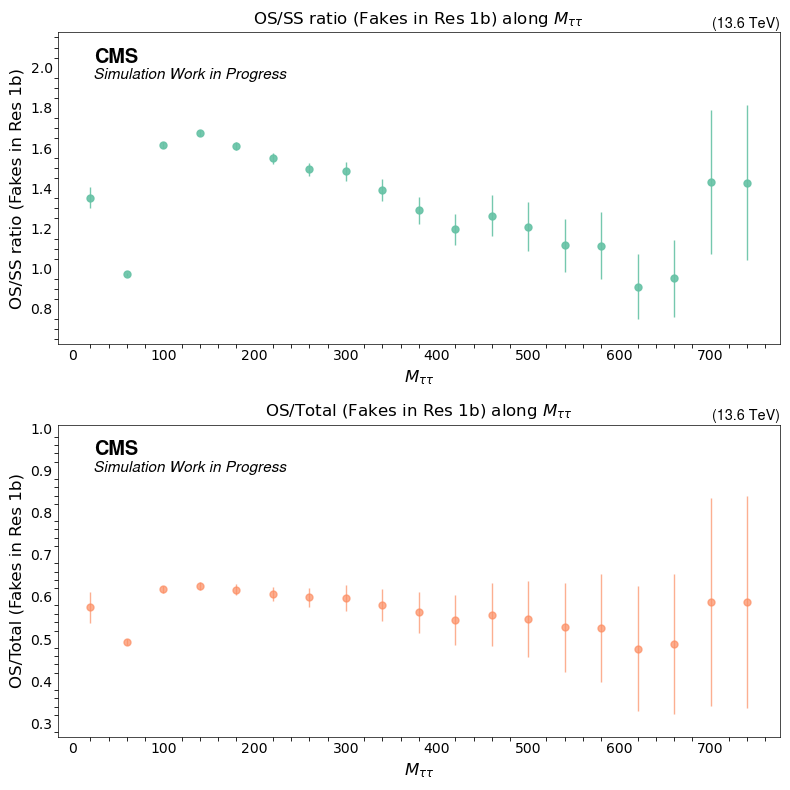

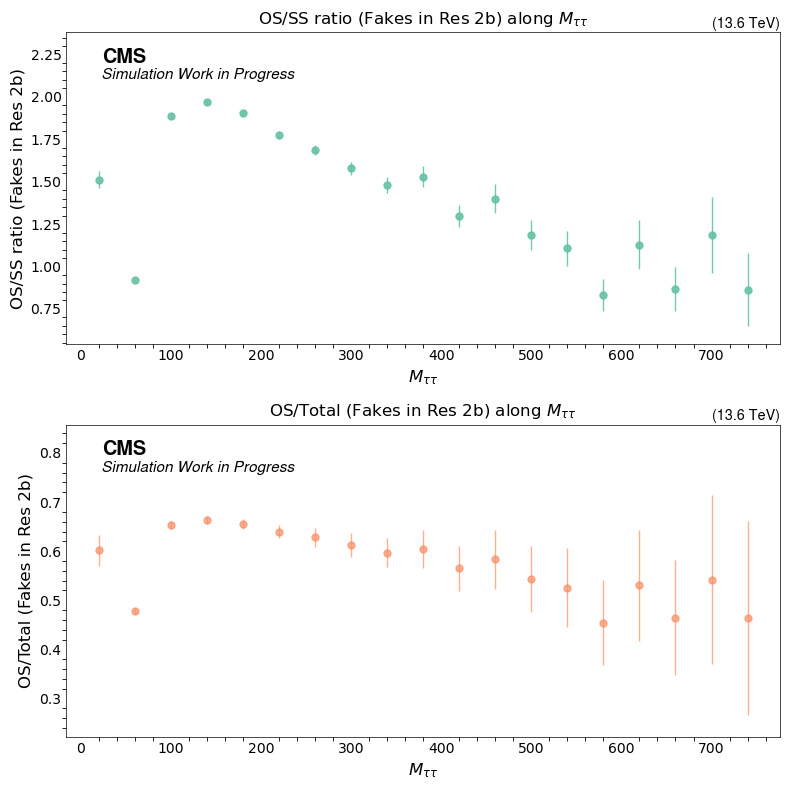

In [10]:
# Plot Correlations
PlotUtil.corr_discrete(df_1b, 'OS', 'DiTau_mass', r'$M_{\tau \tau}$', 'OS/SS ratio (Fakes in Res 1b)', 'OS/Total (Fakes in Res 1b)', f'{plot_dir}/OSRatio_DiTauM_1b.png', 20, (0, 800), 'weight')
PlotUtil.corr_discrete(df_2b, 'OS', 'DiTau_mass', r'$M_{\tau \tau}$', 'OS/SS ratio (Fakes in Res 2b)', 'OS/Total (Fakes in Res 2b)', f'{plot_dir}/OSRatio_DiTauM_2b.png', 20, (0, 800), 'weight')

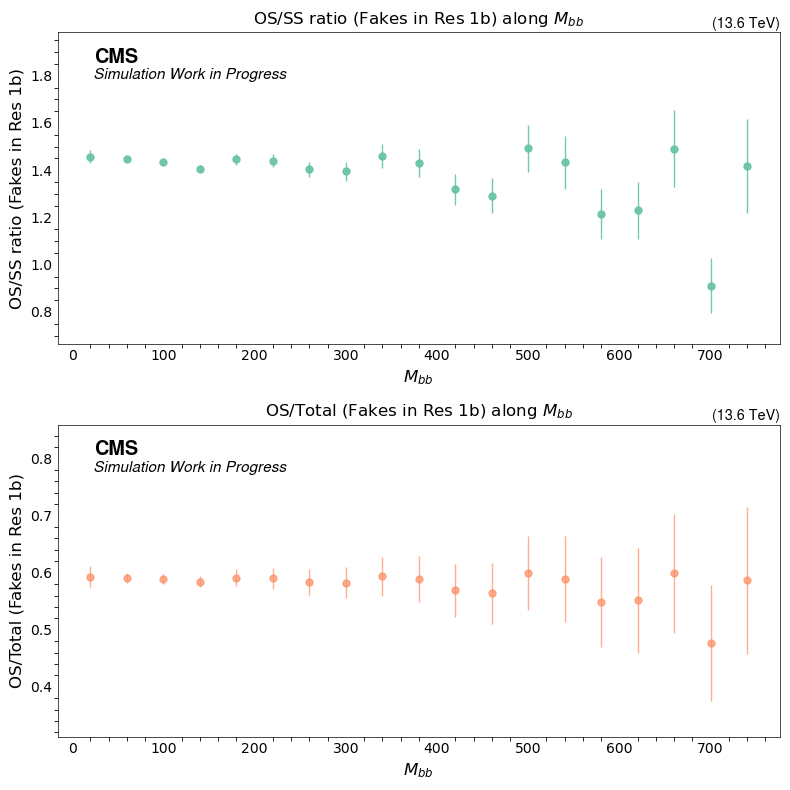

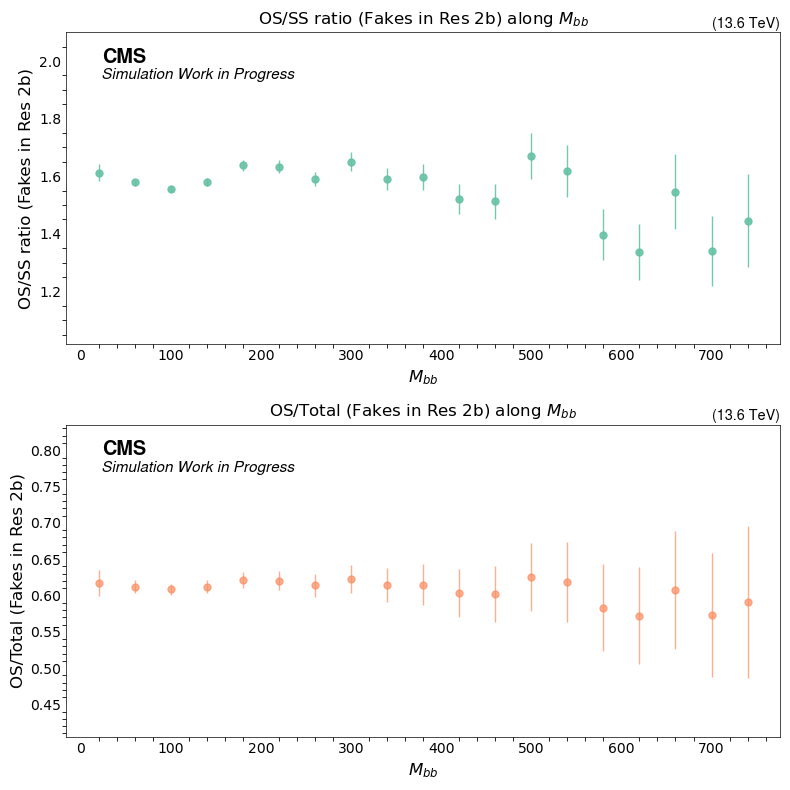

In [13]:
PlotUtil.corr_discrete(df_1b, 'OS', 'DiJet_mass', r'$M_{bb}$', 'OS/SS ratio (Fakes in Res 1b)', 'OS/Total (Fakes in Res 1b)', f'{plot_dir}/OSRatio_DiJetM_1b.png', 20, (0, 800), 'weight')
PlotUtil.corr_discrete(df_2b, 'OS', 'DiJet_mass', r'$M_{bb}$', 'OS/SS ratio (Fakes in Res 2b)', 'OS/Total (Fakes in Res 2b)', f'{plot_dir}/OSRatio_DiJetM_2b.png', 20, (0, 800), 'weight')

In [15]:
# further split the data into training and testing based on tau_id
from scripts.PrepABCD import get_tauid_train_test

ss_1b, val_ss_1b, os_1b, val_os_1b = get_tauid_train_test(Res1b_SS, Res1b_OS)
ss_2b, val_ss_2b, os_2b, val_os_2b = get_tauid_train_test(Res2b_SS, Res2b_OS)

ABCD_Helper = ABCDUtil(val_os_1b, os_1b, val_ss_1b, ss_1b, 'weight')
print("Getting ABCD closure stats for 1b channel")
ABCD_Helper.get_all_stats()
ABCD_Helper = ABCDUtil(val_os_2b, os_2b, val_ss_2b, ss_2b, 'weight')
print("\n \n Getting ABCD closure stats for 2b channel")
ABCD_Helper.get_all_stats()

Getting ABCD closure stats for 1b channel
          Events (Raw)  Events (Weighted)
Region                                   
Region A         59914               3931
Region B        122828               9402
Region C         31507               2126
Region D         91397               7202
The closure stats for Events: 
                                    Raw      Weighted
Metric                                               
Predicted events in A    42342 ± 301.85  2775 ± 74.23
Prediction/Actual ratio           0.707         0.706
Pull significance                54.951        14.118
Deviation                        58.214        15.575
Percentage difference             29.3%         29.4%

 
 Getting ABCD closure stats for 2b channel
          Events (Raw)  Events (Weighted)
Region                                   
Region A         93207               6082
Region B        188790              14486
Region C         41221               2809
Region D        127576              10166

In [52]:
ss_1b, val_ss_1b, os_1b, val_os_1b = get_mbb_train_test(Res1b_SS, Res1b_OS)
ss_2b, val_ss_2b, os_2b, val_os_2b = get_mbb_train_test(Res2b_SS, Res2b_OS)
ABCD_Helper = ABCDUtil(val_os_1b, os_1b, val_ss_1b, ss_1b, 'weight')
print("Getting ABCD closure stats for 1b channel")
ABCD_Helper.get_all_stats()
ABCD_Helper = ABCDUtil(val_os_2b, os_2b, val_ss_2b, ss_2b, 'weight')
print("\n \n Getting ABCD closure stats for 2b channel")
ABCD_Helper.get_all_stats()

Getting ABCD closure stats for 1b channel
          Events (Raw)  Events (Weighted)
Region                                   
Region A         67858               4971
Region B         47934               3456
Region C         45568               3483
Region D         32642               2436
The closure stats for Events: 
                                    Raw       Weighted
Metric                                                
Predicted events in A    66915 ± 573.45  4941 ± 155.21
Prediction/Actual ratio           0.986          0.994
Pull significance                 2.569          0.307
Deviation                         1.644          0.197
Percentage difference              1.4%           0.6%

 
 Getting ABCD closure stats for 2b channel
          Events (Raw)  Events (Weighted)
Region                                   
Region A         98443               7246
Region B        104440               7519
Region C         59614               4618
Region D         61452            

In [53]:
mlp_rwgter = train_mlp_rwgt(ss_2b, os_2b)

Dropped  479  events with negative weights out of  61452  events.
Dropped  749  events with negative weights out of  104440  events.
Features: ['LDTau_pt', 'LDTau_eta', 'LDTau_phi', 'LDTau_mass', 'LDTau_dxy', 'LDTau_dz', 'SDTau_pt', 'SDTau_eta', 'SDTau_phi', 'SDTau_mass', 'SDTau_dxy', 'SDTau_dz', 'nTau_values', 'LDBjet_pt', 'LDBjet_eta', 'LDBjet_phi', 'LDBjet_mass', 'LDBjet_btag', 'LDBjet_pnetbtag', 'LDBjet_pnettau', 'LDBjet_nconstituents', 'SDBjet_pt', 'SDBjet_eta', 'SDBjet_phi', 'SDBjet_mass', 'SDBjet_btag', 'SDBjet_pnetbtag', 'SDBjet_pnettau', 'SDBjet_nconstituents', 'nJets_values', 'DiTau_pt', 'DiTau_eta', 'DiTau_phi', 'DiTau_mass', 'DiJet_pt', 'DiJet_eta', 'DiJet_phi', 'DiJet_mass', 'Tau_dR', 'Bjet_dR', 'RecoH_dR', 'HT', 'LDTau_px', 'LDTau_py', 'LDTau_pz', 'SDTau_px', 'SDTau_py', 'SDTau_pz', 'LDBjet_px', 'LDBjet_py', 'LDBjet_pz', 'SDBjet_px', 'SDBjet_py', 'SDBjet_pz', 'DiTau_px', 'DiTau_py', 'DiTau_pz', 'DiJet_px', 'DiJet_py', 'DiJet_pz']
Epoch 1/100, Train Loss: 0.0490, Val Loss:

In [55]:
drop_kwds = ['Gen', 'weight_values', 'Weight_values', 'OS', 'group', 'gen', 'dataset', 'label', 'id', 'year', 'Tau_charge', 'X_num']
src_df = pd.concat([ss_2b, val_ss_2b], axis=0)
tar_df = pd.concat([os_2b, val_os_2b], axis=0)
total_2b_rwgt = mlp_rwgter.reweight(src_df, tar_df.weight.sum(), drop_kwds, True, 'mlp_rewgt_2b_total') 
# total_1b_rwgt = mlp_rwgter.reweight(src_df, tar_df.weight.sum(), drop_kwds, True, 'mlp_rewgt_1b_total')

Dropped  704  events with negative weights out of  121066  events.


Index(['LDTau_pt', 'LDTau_eta', 'LDTau_phi', 'LDTau_mass', 'LDTau_dxy',
       'LDTau_dz', 'SDTau_pt', 'SDTau_eta', 'SDTau_phi', 'SDTau_mass',
       'SDTau_dxy', 'SDTau_dz', 'nTau_values', 'LDBjet_pt', 'LDBjet_eta',
       'LDBjet_phi', 'LDBjet_mass', 'LDBjet_btag', 'LDBjet_pnetbtag',
       'LDBjet_pnettau', 'LDBjet_nconstituents', 'SDBjet_pt', 'SDBjet_eta',
       'SDBjet_phi', 'SDBjet_mass', 'SDBjet_btag', 'SDBjet_pnetbtag',
       'SDBjet_pnettau', 'SDBjet_nconstituents', 'nJets_values', 'DiTau_pt',
       'DiTau_eta', 'DiTau_phi', 'DiTau_mass', 'DiJet_pt', 'DiJet_eta',
       'DiJet_phi', 'DiJet_mass', 'Tau_dR', 'Bjet_dR', 'RecoH_dR', 'HT',
       'LDTau_px', 'LDTau_py', 'LDTau_pz', 'SDTau_px', 'SDTau_py', 'SDTau_pz',
       'LDBjet_px', 'LDBjet_py', 'LDBjet_pz', 'SDBjet_px', 'SDBjet_py',
       'SDBjet_pz', 'DiTau_px', 'DiTau_py', 'DiTau_pz', 'DiJet_px', 'DiJet_py',
       'DiJet_pz', 'weight', 'LDTau_charge', 'LDTau_jetidx', 'LDTau_idvsjet',
       'LDTau_idvsmu', 'LDTau_idvse'

In [59]:
plot_dir_name = 'TTbar_2b'
savedir = pjoin('training', 'TTbar_only_fake_2b')
out_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/plots/{plot_dir_name}'
data_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/{savedir}'

modified_H_mass = {
    "DiTau_mass": {
        "hist": {'bins': 30, 'range': [0,600]},
        "plot": {'xlabel': r'Visible Mass (2$\tau$) (GeV)'}},
    "DiJet_mass": {
        "hist": {'bins': 40, 'range': [0,800]},
        "plot": {'xlabel': r'Invariant Mass (2b) (GeV)'}},
}
from config.plotsetting import dR, H_pt, HT

def plot_rwgt_results(src_df, tar_df, rwgt_df):
    mbb_plot_config = {
        'list_of_evts': [tar_df, src_df, rwgt_df],
        'labels': ['OS', 'original SS', 'Reweighted SS'],
        'attridict': modified_H_mass,
        'ratio_ylabel': 'Pred/Actual',
        'outdir': out_dir,
        'title': None,
        'save_suffix': 'rwgt'
    }
    
    # For dR
    dr_plot_config = {
        'list_of_evts': [tar_df, src_df, rwgt_df],
        'labels': ['OS', 'original SS', 'Reweighted SS'],
        'attridict': dR,
        'ratio_ylabel': 'Pred/Actual',
        'outdir': out_dir,
        'save_suffix': 'rwgt'
    }

    # For H_pt
    H_pt_plot_config = {
        'list_of_evts': [tar_df, src_df, rwgt_df],
        'labels': ['OS', 'original SS', 'Reweighted SS'],
        'attridict': H_pt,
        'ratio_ylabel': 'Pred/Actual',
        'outdir': out_dir,
        'save_suffix': 'rwgt'
    }
    
    HT_plot_config = {
        'list_of_evts': [tar_df, src_df, rwgt_df],
        'labels': ['OS', 'original SS', 'Reweighted SS'],
        'attridict': HT,
        'ratio_ylabel': 'Pred/Actual',
        'outdir': out_dir,
        'save_suffix': 'rwgt'
    }

    CSVPlotter.plot_shape(**mbb_plot_config)
    CSVPlotter.plot_shape(**dr_plot_config)
    CSVPlotter.plot_shape(**H_pt_plot_config)
    CSVPlotter.plot_shape(**HT_plot_config)

/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:151: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:151: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:151: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:151: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:151: RuntimeWarning: invalid value encountered in divide
  density_hist * (np.sqrt(hist)/hist),


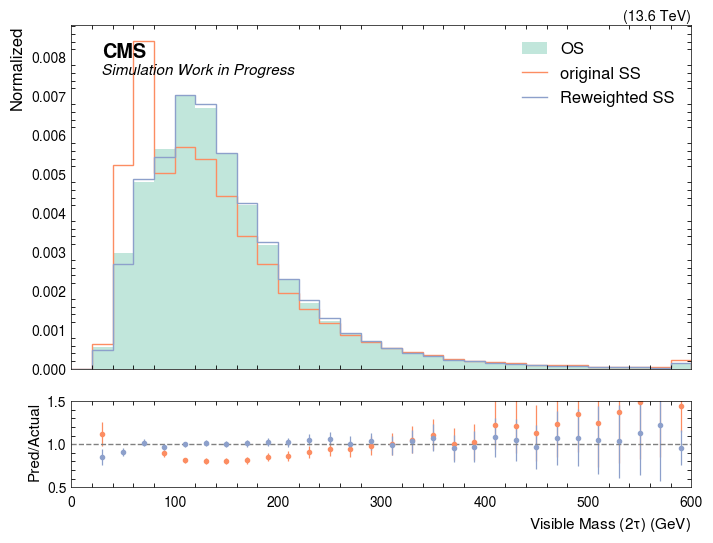

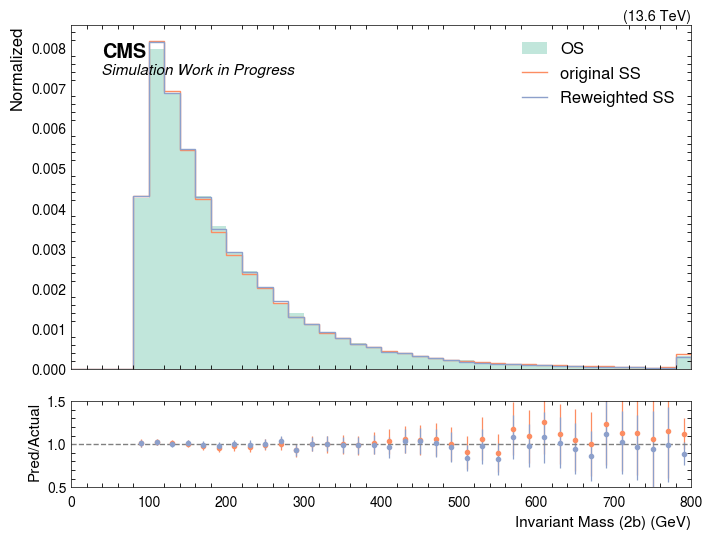

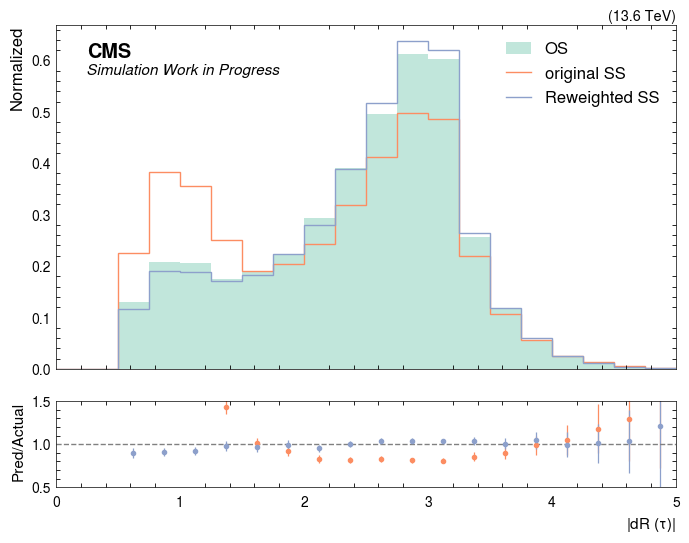

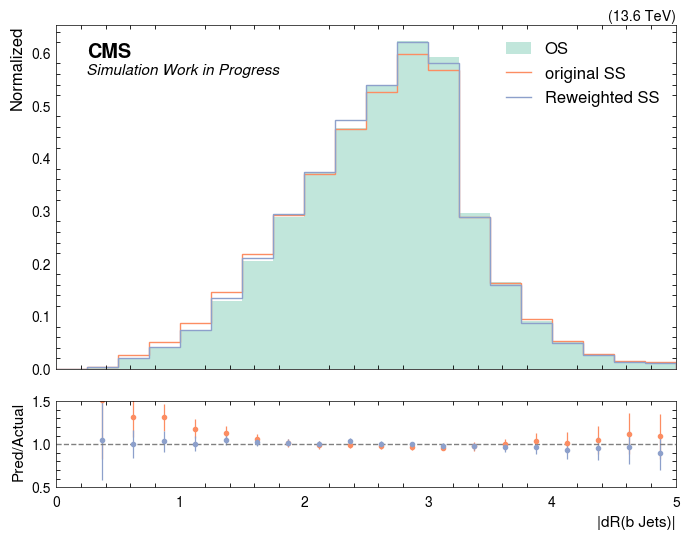

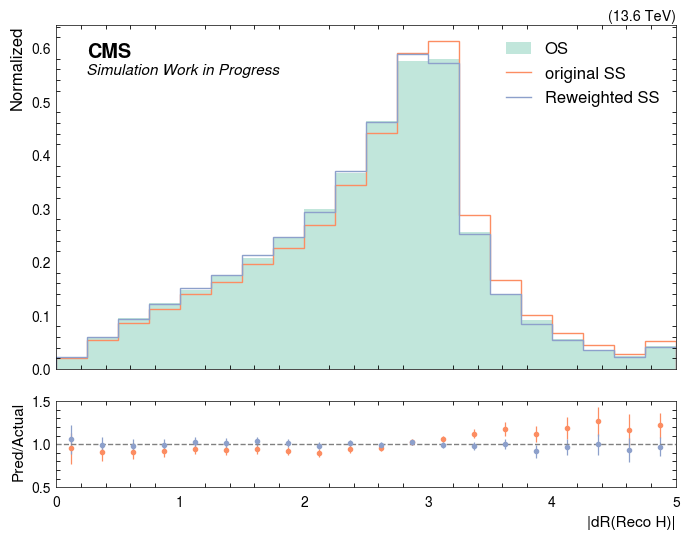

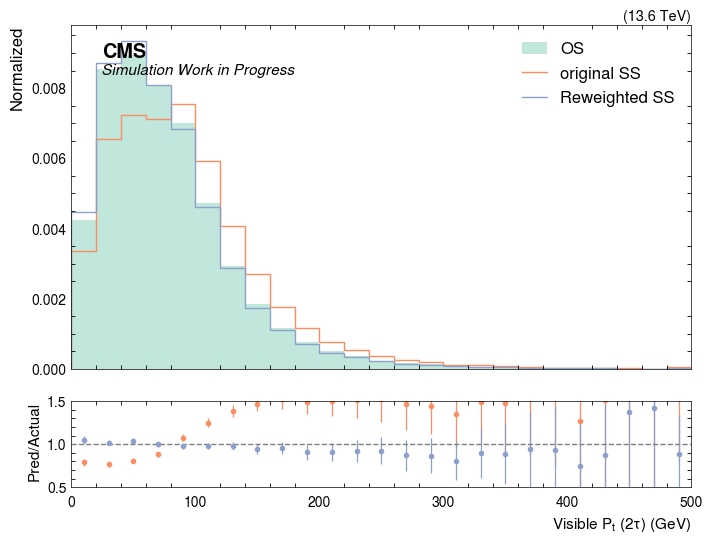

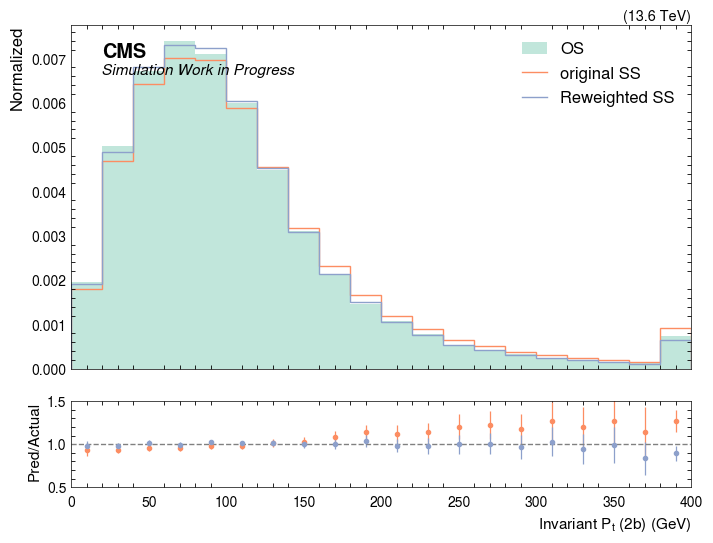

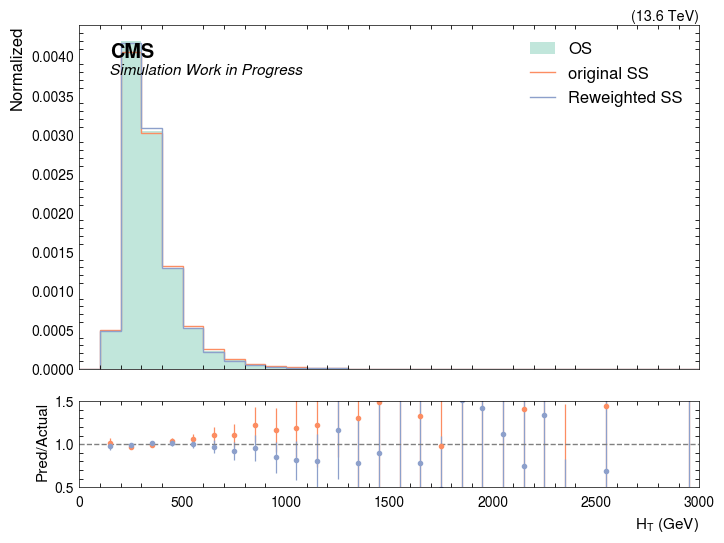

In [60]:
plot_rwgt_results(src_df, tar_df, total_2b_rwgt)